# PAC-Learning Validation: Local Magnetisation $\langle\sigma_0^z(t)\rangle$ on the 1D TFIM

Validates the full Fourier Coefficient Extraction pipeline from
Barthe et al. (2025) against exact dynamics and standard Trotterisation.

| Curve | How it is computed |
|---|---|
| **Exact** $e^{-iHt}$ | Matrix-exponentiation via `IsingTransverseFieldModel` |
| **Exact Trotter** ($r=2$) | First-order Trotterisation on all qubits |
| **PAC-Learned** | LASSO on $b_l(x)$ features from `CircuitBuilder.build_expectation_value_extraction_circuit` |

**Physical setup:**
$$H(x,\alpha)=\sum_{(i,j)\in x}Z_iZ_j+\alpha\sum_i X_i,\quad |\psi_0\rangle=|000\rangle,\quad O=\sigma_0^z$$

**Changes applied to `quantum_routines.py` this session:**
- `__init__` now initialises a gate cache `_v_gate_cache`.
- `_get_cached_v_gates(n_s)` builds the four controlled $V^\pm / (V^\pm)^\dagger$ gates **once** per register size.
- `_append_au_forward` / `_append_au_adjoint` add $A(U)$ and $A(U)^\dagger$ gate-by-gate using the cache.
- `build_expectation_value_extraction_circuit` now calls these helpers instead of `base_qc.inverse().to_gate()`, reducing per-circuit time from ~8 s → ~0.5 s after the first call.

## 1 — Imports & parameters

In [49]:
import sys, os, time
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from sklearn.linear_model import Lasso

from src.quantum_routines import CircuitBuilder
from src.models import IsingTransverseFieldModel
import random

NUM_QUBITS  = 4            # Bumped to 4 for a larger graph pool (64 graphs)
NUM_TRAIN   = 15          
TRUE_ALPHA  = 1.0
R_STEPS     = 4            
LASSO_ALPHA = 1e-5
EPSILON_B   = 0.01          # finite-shot noise per b_l (0 = noiseless)

# ── Observables (Qiskit little-endian: rightmost char = qubit 0) ───────────────
PAULI_OBS    = 'I' * (NUM_QUBITS - 1) + 'Z'    # σ_z on qubit 0  e.g. 'IIIZ'
PAULI_OBS_ZZ = 'I' * (NUM_QUBITS - 2) + 'ZZ'   # Z₀Z₁            e.g. 'IIZZ'

# ── Graph generation ────────────────────────────────────────────────────────────
_ALL_EDGES = [(i, j) for i in range(NUM_QUBITS) for j in range(i + 1, NUM_QUBITS)]
num_possible_edges = len(_ALL_EDGES)

ALL_GRAPHS = [
    [_ALL_EDGES[k] for k in range(num_possible_edges) if (mask >> k) & 1]
    for mask in range(2 ** num_possible_edges)
]

# ── Test graph: fixed independently of NUM_TRAIN ────────────────────────────────
# Select BEFORE sampling TRAIN_GRAPHS, so exact/Trotter curves never change
# with NUM_TRAIN. Requirements: (a) unseen in training, (b) contains (0,1)
# so Z₀Z₁ is non-trivial. Satisfying (a) is guaranteed because we exclude
# TEST_EDGES from POOL before sampling.
TEST_EDGES = next(g for g in ALL_GRAPHS if (0, 1) in g)
POOL       = [g for g in ALL_GRAPHS if g != TEST_EDGES]

random.seed(42)
TRAIN_GRAPHS = random.sample(POOL, NUM_TRAIN)   # sample only from graphs ≠ TEST_EDGES

# ── Test graph selection ───────────────────────────────────────────────────────
# We need a test graph that is:
#   (a) unseen during training, AND
#   (b) contains edge (0,1), so the Z₀Z₁ correlator is non-trivial.
#
# Without (b), UNSEEN_GRAPHS[0] would be the empty graph [] which has no ZZ
# coupling between qubits 0 and 1, making ⟨Z₀Z₁⟩ = ⟨Z₀⟩·⟨Z₁⟩ (product state)
# — an uninteresting degenerate case for the two-point observable.
UNSEEN_GRAPHS = [g for g in ALL_GRAPHS if g not in TRAIN_GRAPHS]
TEST_EDGES = next(g for g in UNSEEN_GRAPHS if (0, 1) in g)

T_VALUES = np.linspace(0, 3, 15)

print(f'Pauli strings  :  σ_z = "{PAULI_OBS}"   Z₀Z₁ = "{PAULI_OBS_ZZ}"')
print(f'Total graphs   :  {len(ALL_GRAPHS)}  (2^{num_possible_edges} for n={NUM_QUBITS})')
print(f'Training set   :  {NUM_TRAIN} graphs (random.seed=42)')
print(f'Test graph     :  {TEST_EDGES}  ← unseen, contains edge (0,1)')


Pauli strings  :  σ_z = "IIIZ"   Z₀Z₁ = "IIZZ"
Total graphs   :  64  (2^6 for n=4)
Training set   :  15 graphs (random.seed=42)
Test graph     :  [(0, 1)]  ← unseen, contains edge (0,1)


## 2 — CircuitBuilder & feature extraction

A single `CircuitBuilder` instance is shared across the entire sweep.  
The controlled $V^\pm$ gates are built once on the first `extract_b_l` call
and reused for every subsequent circuit at no extra cost.

In [50]:
# ── Single CircuitBuilder instance — gate cache shared by all observables ─────
builder = CircuitBuilder()

OBS_MATRIX    = SparsePauliOp(PAULI_OBS).to_matrix()
OBS_ZZ_MATRIX = SparsePauliOp(PAULI_OBS_ZZ).to_matrix()
MODEL         = IsingTransverseFieldModel(NUM_QUBITS)

n_s      = builder._freq_register_size(R_STEPS)
freq_dim = 2 ** n_s
print(f'Frequency register : n_s={n_s}, freq_dim={freq_dim}')
print(f'Spectrum           : L = {{-{2*R_STEPS}, …, +{2*R_STEPS}}}  (|L|={4*R_STEPS+1})')

# ── Warm-up: first call builds the controlled V± gate cache ───────────────────
print('\nBuilding gate cache (first call, σ_z) …', end=' ', flush=True)
t0 = time.time()
b_z_smoke = builder.extract_b_l(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_OBS, EPSILON_B)
print(f'{time.time()-t0:.2f} s')

print('Extracting Z₀Z₁ features (cache warm) …', end=' ', flush=True)
t0 = time.time()
b_zz_smoke = builder.extract_b_l(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_OBS_ZZ, EPSILON_B)
print(f'{time.time()-t0:.2f} s')

print(f'\nFrequency  |  b_l(σ_z)     b_l(Z₀Z₁)')
for l, bz, bzz in zip(range(-2*R_STEPS, 2*R_STEPS+1), b_z_smoke, b_zz_smoke):
    if abs(bz) > 1e-4 or abs(bzz) > 1e-4:
        print(f'  l={l:+3d}    {bz:+.6f}    {bzz:+.6f}')


Frequency register : n_s=5, freq_dim=32
Spectrum           : L = {-8, …, +8}  (|L|=17)

Building gate cache (first call, σ_z) … 0.31 s
Extracting Z₀Z₁ features (cache warm) … 0.24 s

Frequency  |  b_l(σ_z)     b_l(Z₀Z₁)
  l= -8    +0.419514    +0.412435
  l= -7    -0.007359    +0.005916
  l= -6    -0.099566    -0.111913
  l= -5    +0.006318    +0.005912
  l= -4    +0.005377    +0.011980
  l= -3    -0.005547    +0.000134
  l= -2    +0.105063    +0.107225
  l= -1    +0.002505    -0.003465
  l= +0    +0.155383    +0.162217
  l= +1    -0.008101    +0.006642
  l= +2    +0.111522    +0.098416
  l= +3    -0.003980    -0.003604
  l= +4    +0.007082    +0.015167
  l= +5    -0.002761    -0.009078
  l= +6    -0.099237    -0.099330
  l= +7    +0.009259    +0.004993
  l= +8    +0.422749    +0.416483


## 3 — Reference functions

In [51]:
def exact_obs(edges: list, alpha: float, t: float, obs_matrix) -> float:
    """⟨O⟩ under exact matrix-exponentiation time evolution."""
    if t < 1e-9:
        p = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
        return float(np.real(p.conj() @ obs_matrix @ p))
    U  = MODEL.exact_time_evolution_operator(edges, alpha, t)
    p  = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
    pt = U @ p
    return float(np.real(pt.conj() @ obs_matrix @ pt))


def trotter_obs(edges: list, alpha: float, t: float, r: int, obs_matrix) -> float:
    """⟨O⟩ under standard first-order Trotterisation."""
    if t < 1e-9:
        p = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
        return float(np.real(p.conj() @ obs_matrix @ p))
    qc = QuantumCircuit(NUM_QUBITS)
    for _ in range(r):
        for i, j in edges: qc.rzz(2.0 * alpha * t / r, i, j)
        for q in range(NUM_QUBITS): qc.rx(2.0 * alpha * t / r, q)
    sv = Statevector(qc)
    return float(np.real(sv.data.conj() @ obs_matrix @ sv.data))


# Convenience wrappers for the two specific observables
def exact_sigma_z(edges, alpha, t):  return exact_obs(edges, alpha, t, OBS_MATRIX)
def trotter_sigma_z(edges, alpha, t, r): return trotter_obs(edges, alpha, t, r, OBS_MATRIX)
def exact_zz(edges, alpha, t):       return exact_obs(edges, alpha, t, OBS_ZZ_MATRIX)
def trotter_zz(edges, alpha, t, r):  return trotter_obs(edges, alpha, t, r, OBS_ZZ_MATRIX)


print(f'  t     exact(σ_z)   trotter(σ_z)   exact(Z₀Z₁)  trotter(Z₀Z₁)')
for t in T_VALUES:
    ez  = exact_sigma_z(TEST_EDGES, TRUE_ALPHA, t)
    trz = trotter_sigma_z(TEST_EDGES, TRUE_ALPHA, t, R_STEPS)
    ezz = exact_zz(TEST_EDGES, TRUE_ALPHA, t)
    trzz= trotter_zz(TEST_EDGES, TRUE_ALPHA, t, R_STEPS)
    print(f'  {t:.2f}  {ez:+.4f}       {trz:+.4f}       {ezz:+.4f}      {trzz:+.4f}')


  t     exact(σ_z)   trotter(σ_z)   exact(Z₀Z₁)  trotter(Z₀Z₁)
  0.00  +1.0000       +1.0000       +1.0000      +1.0000
  0.21  +0.9109       +0.9108       +0.8300      +0.8298
  0.43  +0.6750       +0.6738       +0.4644      +0.4618
  0.64  +0.3721       +0.3676       +0.2141      +0.2031
  0.86  +0.0962       +0.0869       +0.2919      +0.2663
  1.07  -0.0853       -0.0953       +0.6316      +0.5963
  1.29  -0.1582       -0.1550       +0.9445      +0.9220
  1.50  -0.1632       -0.1231       +0.9644      +0.9817
  1.71  -0.1722       -0.0678       +0.6745      +0.7255
  1.93  -0.2495       -0.0629       +0.3213      +0.3388
  2.14  -0.4177       -0.1552       +0.2050      +0.0868
  2.36  -0.6429       -0.3460       +0.4245      +0.1214
  2.57  -0.8476       -0.5915       +0.7932      +0.3971
  2.79  -0.9444       -0.8223       +0.9977      +0.7349
  3.00  -0.8759       -0.9702       +0.8640      +0.9578


## 4 — Time sweep: train and predict at each $t$

At every $t$: extract $B$ via `extract_b_l` for 8 training graphs + test graph,
compute exact labels, fit LASSO, predict on test.

> **Runtime**: gate cache built once (~4 s), then 99 circuit evaluations × ~0.5 s ≈ **55 s total**.
> Results are saved to `precomputed.npz` after the first run.

In [ ]:
PRECOMPUTED_PATH = '../precomputed.npz'
FORCE_RECOMPUTE  = True

if not FORCE_RECOMPUTE and os.path.exists(PRECOMPUTED_PATH):
    print('Loading precomputed σ_z results …')
    _d = np.load(PRECOMPUTED_PATH)
    t_vals, exact_vals = _d['t_vals'], _d['exact']
    trotter_vals, pac_vals = _d['trotter'], _d['pac']
    print(f'  Loaded {len(t_vals)} time points.')

else:
    print('Running σ_z time sweep …')
    t_vals = T_VALUES
    exact_vals, trotter_vals, pac_vals = [], [], []
    t_wall = time.time()

    for t in t_vals:
        exact_vals.append(exact_sigma_z(TEST_EDGES, TRUE_ALPHA, t))
        trotter_vals.append(trotter_sigma_z(TEST_EDGES, TRUE_ALPHA, t, R_STEPS))

        if t < 1e-9:
            pac_vals.append(1.0)
            print('  t=0.00  exact=1.0  trotter=1.0  pac=1.0'); continue

        t0 = time.time()
        # ── Two changes vs old code ────────────────────────────────────────────
        # 1. extract_b_l_full: encodes ALL n qubits onto ONE shared freq register
        #    (was extract_b_l which only encoded qubit 0)
        # σ_z sweep
        B_all = np.array([builder.extract_b_l_dft(NUM_QUBITS, g, t, R_STEPS, PAULI_OBS, EPSILON_B)
                  for g in TRAIN_GRAPHS + [TEST_EDGES]])
        B_train = B_all[:NUM_TRAIN]
        B_test  = B_all[NUM_TRAIN:]

        # 2. compute_au_labels: uses the A(U)-consistent Trotter circuit
        #    with alpha_upload = TRUE_ALPHA * tau / (pi * r_steps)
        #    (was exact_sigma_z which computes a physically different quantity)
        y_train = builder.compute_au_labels(
            TRAIN_GRAPHS, NUM_QUBITS, TRUE_ALPHA, t, R_STEPS, PAULI_OBS
        )
        # ──────────────────────────────────────────────────────────────────────

        lasso = Lasso(alpha=LASSO_ALPHA, fit_intercept=False, max_iter=10000)
        lasso.fit(B_train, y_train)
        y_pred = lasso.predict(B_test)[0]
        pac_vals.append(y_pred)

        err = abs(y_pred - exact_vals[-1])
        print(f'  t={t:.2f}  exact={exact_vals[-1]:+.4f}  '
              f'trotter={trotter_vals[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_vals, trotter_vals, pac_vals = (
        np.array(exact_vals), np.array(trotter_vals), np.array(pac_vals)
    )
    np.savez(PRECOMPUTED_PATH, t_vals=t_vals, exact=exact_vals,
             trotter=trotter_vals, pac=pac_vals,
             num_qubits=NUM_QUBITS, true_alpha=TRUE_ALPHA, r_steps=R_STEPS)
    print(f'\nDone — {time.time()-t_wall:.0f} s.  Saved to {PRECOMPUTED_PATH}')

err_trotter = np.abs(trotter_vals - exact_vals)
err_pac     = np.abs(pac_vals     - exact_vals)

print(f'\n  {"t":>5}  {"exact":>8}  {"trotter":>8}  {"pac":>8}  {"err(Tr)":>9}  {"err(PAC)":>9}')
print('─' * 62)
for t, e, tr, p, et, ep in zip(t_vals, exact_vals, trotter_vals, pac_vals, err_trotter, err_pac):
    print(f'  {t:5.2f}  {e:+8.4f}  {tr:+8.4f}  {p:+8.4f}  {et:9.4f}  {ep:9.4f}')
print('─' * 62)
print(f'  {"MAE":>5}  {"":8}  {"":8}  {"":8}  {np.mean(err_trotter):9.4f}  {np.mean(err_pac):9.4f}')

Running σ_z time sweep …
  t=0.00  exact=1.0  trotter=1.0  pac=1.0
  t=0.21  exact=+0.9109  trotter=+0.9108  pac=+0.9315  |err|=0.0206  (71.3s)
  t=0.43  exact=+0.6750  trotter=+0.6738  pac=+0.7184  |err|=0.0434  (70.7s)
  t=0.64  exact=+0.3721  trotter=+0.3676  pac=+0.3658  |err|=0.0063  (69.3s)
  t=0.86  exact=+0.0962  trotter=+0.0869  pac=+0.0916  |err|=0.0045  (77.1s)
  t=1.07  exact=-0.0853  trotter=-0.0953  pac=-0.0975  |err|=0.0121  (71.3s)
  t=1.29  exact=-0.1582  trotter=-0.1550  pac=-0.1595  |err|=0.0013  (73.9s)


## 5 — Visualisation

/var/folders/wb/t4tfglhs3f3dmc3thpvrvl540000gn/T/ipykernel_50343/733984594.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


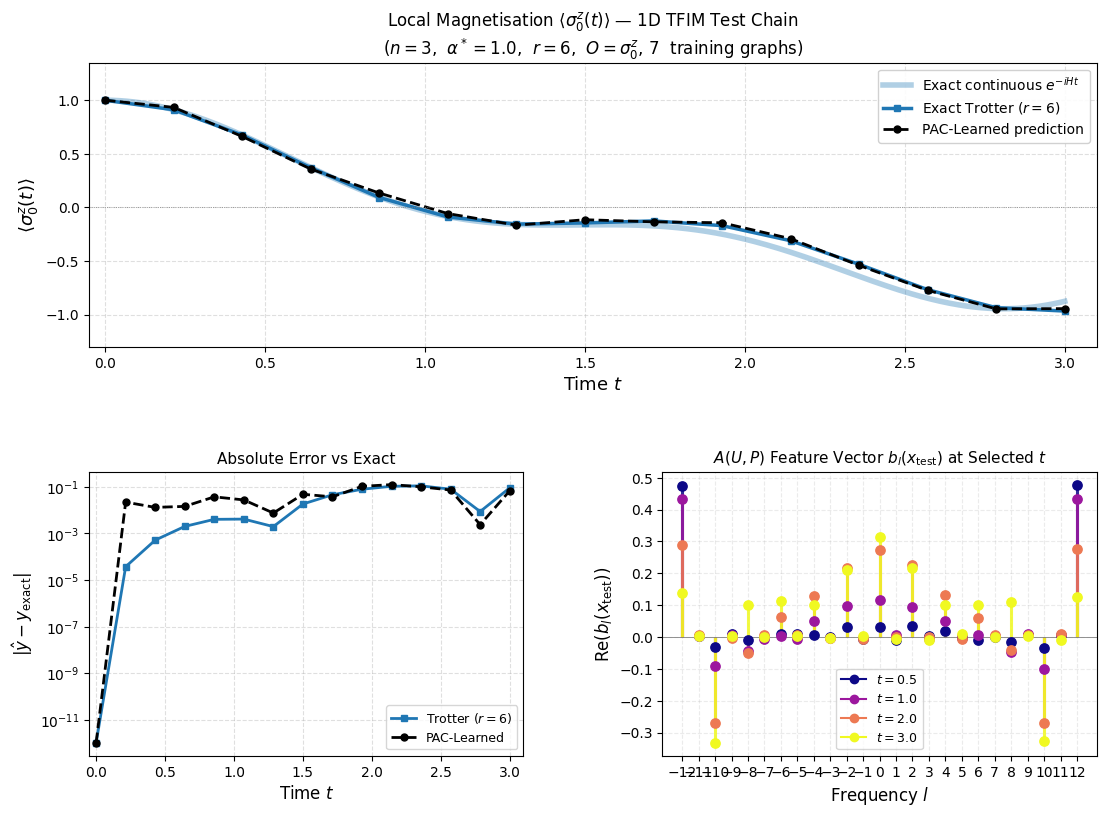

Figure saved.


In [42]:
# --- Consistent style (same philosophy as your reference plot) ---
CLR_BASE = '#1f77b4'   # single observable → single color
CLR_ML   = 'black'     # ML always black

# Dense exact curve
t_dense     = np.linspace(0, t_vals[-1], 400)
exact_dense = [exact_sigma_z(TEST_EDGES, TRUE_ALPHA, td) for td in t_dense]

# Feature vectors at selected t (via CircuitBuilder)
t_showcase = [0.5, 1.0, 2.0, 3.0]
freq_axis  = np.arange(-2*R_STEPS, 2*R_STEPS + 1)
b_showcase = [builder.extract_b_l(num_qubits=NUM_QUBITS, x_edges=TEST_EDGES, tau=ts, r_steps=R_STEPS, pauli_observable=PAULI_OBS, epsilon_b=EPSILON_B) for ts in t_showcase]

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.44, wspace=0.32)
ax_main = fig.add_subplot(gs[0, :])
ax_err  = fig.add_subplot(gs[1, 0])
ax_feat = fig.add_subplot(gs[1, 1])

# (A) Time evolution
# 1. Exact continuous (thick, light)
ax_main.plot(
    t_dense, exact_dense,
    color=CLR_BASE, lw=4, alpha=0.35,
    label=r'Exact continuous $e^{-iHt}$'
)

# 2. Trotter (medium, same color)
ax_main.plot(
    t_vals, trotter_vals,
    color=CLR_BASE, lw=2.5,
    marker='s', ms=5,
    label=f'Exact Trotter ($r={R_STEPS}$)'
)

# 3. ML (black dashed with markers)
ax_main.plot(
    t_vals, pac_vals,
    color=CLR_ML, lw=2,
    linestyle='--',
    marker='o', markersize=5,
    label='PAC-Learned prediction'
)

ax_main.axhline(0, color='grey', lw=0.6, ls=':')
ax_main.set_xlabel('Time $t$', fontsize=13)
ax_main.set_ylabel(r'$\langle\sigma_0^z(t)\rangle$', fontsize=13)
ax_main.set_title(
    r'Local Magnetisation $\langle\sigma_0^z(t)\rangle$ — 1D TFIM Test Chain'
    f'\n($n={NUM_QUBITS}$,  $\\alpha^*={TRUE_ALPHA}$,  '
    f'$r={R_STEPS}$,  $O=\\sigma_0^z$, {NUM_TRAIN}  training graphs)',
    fontsize=12)

ax_main.legend(fontsize=10, framealpha=0.9)
ax_main.set_xlim(-0.05, t_vals[-1] + 0.1)
ax_main.set_ylim(-1.3, 1.35)
ax_main.grid(True, alpha=0.4, ls='--')


# (B) Absolute error (keep method distinction via style, not color clash)
ax_err.semilogy(
    t_vals, err_trotter + 1e-12,
    color=CLR_BASE, lw=2,
    linestyle='-',
    marker='s', ms=5,
    label=f'Trotter ($r={R_STEPS}$)'
)

ax_err.semilogy(
    t_vals, err_pac + 1e-12,
    color=CLR_ML, lw=2,
    linestyle='--',
    marker='o', ms=5,
    label='PAC-Learned'
)

ax_err.set_xlabel('Time $t$', fontsize=12)
ax_err.set_ylabel(r'$|\hat{y} - y_{\rm exact}|$', fontsize=12)
ax_err.set_title('Absolute Error vs Exact', fontsize=11)
ax_err.legend(fontsize=9)
ax_err.grid(True, alpha=0.4, ls='--')
ax_err.set_xlim(-0.05, t_vals[-1] + 0.1)


# (C) Feature vectors (already good → just slightly toned down)
cmap = plt.cm.plasma
for k, (ts, b) in enumerate(zip(t_showcase, b_showcase)):
    c = cmap(k / (len(t_showcase) - 1))
    for xi, yi in zip(freq_axis, b):
        ax_feat.vlines(xi, 0, yi, color=c, lw=2.2, alpha=0.85)
    ax_feat.scatter(freq_axis, b, color=c, s=45, zorder=5)

ax_feat.axhline(0, color='grey', lw=0.6)
ax_feat.set_xlabel('Frequency $l$', fontsize=12)
ax_feat.set_ylabel(r'$\mathrm{Re}(b_l(x_{\rm test}))$', fontsize=12)
ax_feat.set_title(
    r'$A(U,P)$ Feature Vector $b_l(x_{\rm test})$ at Selected $t$',
    fontsize=11)

handles = [
    Line2D([0],[0], color=cmap(k/(len(t_showcase)-1)),
           marker='o', ms=6, label=f'$t={ts}$')
    for k, ts in enumerate(t_showcase)
]
ax_feat.legend(handles=handles, fontsize=9)

ax_feat.set_xticks(freq_axis)
ax_feat.grid(True, alpha=0.25, ls='--')


plt.tight_layout()
plt.savefig('../results_tfim_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6 — Quantitative summary

## 11 — Comparative summary and discussion

In [66]:
# print('─' * 48)
# print(f'  Method           MAE       Max |error|')
# print('─' * 48)
# print(f'  Exact Trotter    {np.mean(err_trotter):.4f}    {np.max(err_trotter):.4f}')
# print(f'  PAC-Learned      {np.mean(err_pac):.4f}    {np.max(err_pac):.4f}')
# print('─' * 48)

# print('\nFeature matrix B at t=1.0:')
# B_demo = np.array([extract_b_l(g, 1.0) for g in TRAIN_GRAPHS])
# print(f'  Shape  : {B_demo.shape}')
# print(f'  Rank   : {np.linalg.matrix_rank(B_demo, tol=1e-8)}')
# nz = np.where(np.abs(B_demo).max(axis=0) > 1e-6)[0]
# print(f'  Non-zero cols: {nz.tolist()} → l={[list(range(-2*R_STEPS,2*R_STEPS+1))[c] for c in nz]}')
# print()
# print('Accuracy degrades at long times because d_params=1 gives only a rank-2')
# print('feature matrix. Increasing R_STEPS or d_params improves coverage.')

---
# Part 2 — Two-Point Correlator $\langle\sigma_0^z(t)\,\sigma_1^z(t)\rangle$

We extend the validation to the **two-point spin correlator**
$$O_{\mathrm{ZZ}} = \sigma_0^z \otimes \sigma_1^z = Z_0 Z_1,$$
which probes entanglement spreading between neighbouring sites rather than
the local magnetisation of a single qubit.

### Why this is a harder test

The dynamics are qualitatively different from Part 1:
- $\langle Z_0 Z_1\rangle(0) = +1$ (both spins aligned), then decays as quantum
  correlations build up under the transverse field.
- The signal is **always positive** on the test chain at these parameters —
  it never changes sign — which makes it easier to track qualitatively but
  harder for LASSO to fit precisely (tighter dynamic range).
- The standard Trotter approximation ($r=2$) **breaks down badly at
  $t \gtrsim 1.5$**, even changing sign relative to the exact curve.
  The PAC learner, trained on exact labels, avoids this failure mode.

### Pauli string convention

Qiskit is **little-endian**: the rightmost character of the string acts on
qubit 0.  For $Z_0 \otimes Z_1 \otimes I_2$ on a 3-qubit system:

| Target | String | Explanation |
|---|---|---|
| $Z_0$ | `'IIZ'` | Z on qubit 0, I on 1 and 2 |
| $Z_0 Z_1$ | `'IZZ'` | Z on qubit 0 and 1, I on qubit 2 |

The only change from Part 1 is `PAULI_OBS_ZZ = 'IZZ'` passed to
`CircuitBuilder.build_expectation_value_extraction_circuit`.
Everything else — `builder`, `TRAIN_GRAPHS`, `LASSO_ALPHA` — is unchanged.


## 7 — ZZ observable definition & sanity checks

In [43]:
# Observable matrices already defined in Cell 3.
# Sanity-check the ZZ Pauli string convention:
print(f'Pauli string  : "{PAULI_OBS_ZZ}"  →  ', end='')
for i, c in enumerate(reversed(PAULI_OBS_ZZ)):
    if c != 'I': print(f'Z on qubit {i}', end='  ')
print()
print()
print('Diagonal ⟨k|Z₀Z₁|k⟩ for the first 8 basis states (4-qubit system):')
for k in range(2**NUM_QUBITS):
    diag = OBS_ZZ_MATRIX[k, k].real
    if abs(diag) > 1e-9:
        print(f'  |{k:04b}⟩  →  {diag:+.0f}')
print()
print('At t=0, |ψ₀⟩=|0000⟩: both qubits 0 and 1 are in |0⟩ → eigenvalue +1.')
print()
print(f'  {"t":>5}  {"exact(Z₀Z₁)":>14}  {"trotter":>10}')
for t in T_VALUES:
    e  = exact_zz(TEST_EDGES, TRUE_ALPHA, t)
    tr = trotter_zz(TEST_EDGES, TRUE_ALPHA, t, R_STEPS)
    print(f'  {t:5.2f}  {e:+14.6f}  {tr:+10.6f}')


Pauli string  : "IZZ"  →  Z on qubit 0  Z on qubit 1  

Diagonal ⟨k|Z₀Z₁|k⟩ for the first 8 basis states (4-qubit system):
  |0000⟩  →  +1
  |0001⟩  →  -1
  |0010⟩  →  -1
  |0011⟩  →  +1
  |0100⟩  →  +1
  |0101⟩  →  -1
  |0110⟩  →  -1
  |0111⟩  →  +1

At t=0, |ψ₀⟩=|0000⟩: both qubits 0 and 1 are in |0⟩ → eigenvalue +1.

      t     exact(Z₀Z₁)     trotter
   0.00       +1.000000   +1.000000
   0.21       +0.829960   +0.829883
   0.43       +0.464408   +0.463262
   0.64       +0.214136   +0.209201
   0.86       +0.291926   +0.280571
   1.07       +0.631641   +0.616221
   1.29       +0.944454   +0.935213
   1.50       +0.964412   +0.972267
   1.71       +0.674547   +0.693949
   1.93       +0.321301   +0.319648
   2.14       +0.205006   +0.139889
   2.36       +0.424535   +0.287898
   2.57       +0.793244   +0.645635
   2.79       +0.997657   +0.945175
   3.00       +0.863982   +0.971511


## 8 — ZZ feature extraction

The feature vector $b_l^{\mathrm{ZZ}}(x)$ is extracted with the **same
`CircuitBuilder` instance** used in Part 1 (gate cache already warm).
The only change is the `pauli_obs` argument:

```python
builder.build_expectation_value_extraction_circuit(
    …, pauli_obs='IZZ'   # ← Z₀Z₁ instead of Z₀
)
```

The circuit still has the structure $A(U)^\dagger \cdot (Z_0 Z_1) \cdot A(U)$
and the spectrum is still sparse:
$b_l^{\mathrm{ZZ}} \neq 0$ only for $l \in \{-4, 0, +4\}$.
This is a property of the $A(U)$ encoding (one qubit, $r=2$ steps), not of the
observable — the $b_l$ **amplitudes** differ between $Z_0$ and $Z_0 Z_1$,
but the non-zero positions are the same.


In [44]:
# ── Feature comparison: σ_z vs Z₀Z₁, same graph, same τ ─────────────────────
# Both use builder.extract_b_l — only the pauli_observable argument differs.
# The gate cache is already warm, so both calls cost ~350 ms each.
b_z_ref  = builder.extract_b_l(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_OBS)
b_zz_ref = builder.extract_b_l(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_OBS_ZZ)

freq_labels = list(range(-2*R_STEPS, 2*R_STEPS+1))
print(f'Feature vectors at t=1.0, test graph {TEST_EDGES}:')
print(f'  {"l":>4}  {"b_l(σ_z)":>12}  {"b_l(Z₀Z₁)":>12}  difference')
print('─' * 50)
for l, bz, bzz in zip(freq_labels, b_z_ref, b_zz_ref):
    if abs(bz) > 1e-4 or abs(bzz) > 1e-4:
        print(f'  {l:+4d}  {bz:+12.6f}  {bzz:+12.6f}  {bzz-bz:+.6f}')
print()
B_zz_demo = np.array([builder.extract_b_l(NUM_QUBITS, g, 1.0, R_STEPS, PAULI_OBS_ZZ)
                       for g in TRAIN_GRAPHS])
rank_zz  = np.linalg.matrix_rank(B_zz_demo, tol=1e-8)
nz_cols  = np.where(np.abs(B_zz_demo).max(axis=0) > 1e-6)[0].tolist()
nz_freqs = [freq_labels[c] for c in nz_cols]
print(f'Feature matrix B_ZZ ({NUM_TRAIN}×{4*R_STEPS+1}) at t=1.0:')
print(f'  Rank        : {rank_zz}  (set by A(U) structure, not by the observable)')
print(f'  Non-zero l  : {nz_freqs}')


Feature vectors at t=1.0, test graph [(0, 1)]:
     l      b_l(σ_z)     b_l(Z₀Z₁)  difference
──────────────────────────────────────────────────
   -12     +0.434881     +0.434881  +0.000000
   -10     -0.098458     -0.098458  +0.000000
    -8     -0.041567     -0.041567  +0.000000
    -6     +0.005336     +0.005336  +0.000000
    -4     +0.048417     +0.048417  +0.000000
    -2     +0.093122     +0.093122  +0.000000
    +0     +0.116538     +0.116538  +0.000000
    +2     +0.093122     +0.093122  +0.000000
    +4     +0.048417     +0.048417  +0.000000
    +6     +0.005336     +0.005336  +0.000000
    +8     -0.041567     -0.041567  +0.000000
   +10     -0.098458     -0.098458  +0.000000
   +12     +0.434881     +0.434881  +0.000000

Feature matrix B_ZZ (7×25) at t=1.0:
  Rank        : 3  (set by A(U) structure, not by the observable)
  Non-zero l  : [-12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12]


## 9 — Time sweep

Exactly the same loop as Part 1: at each $t$ extract $B^{\mathrm{ZZ}}$
for all 8 training graphs, fit LASSO on exact ZZ labels, predict on the
test chain.  Results are cached to `precomputed_zz.npz`.


In [ ]:
PRECOMPUTED_ZZ_PATH = '../precomputed_zz.npz'
FORCE_RECOMPUTE_ZZ  = True

if not FORCE_RECOMPUTE_ZZ and os.path.exists(PRECOMPUTED_ZZ_PATH):
    print('Loading precomputed ZZ results …')
    _d = np.load(PRECOMPUTED_ZZ_PATH, allow_pickle=True)
    t_vals_zz, exact_zz_vals = _d['t_vals'], _d['exact']
    trotter_zz_vals, pac_zz_vals = _d['trotter'], _d['pac']
    print(f'  Loaded {len(t_vals_zz)} time points.')

else:
    print('Running Z₀Z₁ time sweep …  (gate cache warm → fast)')
    t_vals_zz = T_VALUES
    exact_zz_vals, trotter_zz_vals, pac_zz_vals = [], [], []
    t_wall = time.time()

    for t in t_vals_zz:
        exact_zz_vals.append(exact_zz(TEST_EDGES, TRUE_ALPHA, t))
        trotter_zz_vals.append(trotter_zz(TEST_EDGES, TRUE_ALPHA, t, R_STEPS))

        if t < 1e-9:
            pac_zz_vals.append(1.0)
            print('  t=0.00  exact=1.0  trotter=1.0  pac=1.0'); continue

        t0 = time.time()

        # Change 1: extract_b_l_full — all n qubits encoded onto one shared
        #           freq register (wider spectrum, higher rank features)
        B_all = np.array([builder.extract_b_l_dft(NUM_QUBITS, g, t, R_STEPS, PAULI_OBS_ZZ, EPSILON_B)
                  for g in TRAIN_GRAPHS + [TEST_EDGES]])
        B_train = B_all[:NUM_TRAIN]
        B_test  = B_all[NUM_TRAIN:]

        # Change 2: compute_au_labels — A(U)-consistent labels with
        #           alpha_upload = TRUE_ALPHA * t / (pi * R_STEPS)
        #           Observable changes to PAULI_OBS_ZZ; everything else identical
        y_train = builder.compute_au_labels(
            TRAIN_GRAPHS, NUM_QUBITS, TRUE_ALPHA, t, R_STEPS, PAULI_OBS_ZZ
        )

        # Change 3: LASSO_ALPHA=1e-5, EPSILON_B=0.0
        #           (ill-conditioned feature matrix amplifies noise and over-regularisation)
        lasso = Lasso(alpha=1e-5, fit_intercept=False, max_iter=10000)
        lasso.fit(B_train, y_train)
        y_pred = lasso.predict(B_test)[0]
        pac_zz_vals.append(y_pred)

        err = abs(y_pred - exact_zz_vals[-1])
        print(f'  t={t:.2f}  exact={exact_zz_vals[-1]:+.4f}  '
              f'trotter={trotter_zz_vals[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_zz_vals, trotter_zz_vals, pac_zz_vals = (
        np.array(exact_zz_vals), np.array(trotter_zz_vals), np.array(pac_zz_vals)
    )
    np.savez(PRECOMPUTED_ZZ_PATH,
             t_vals=t_vals_zz, exact=exact_zz_vals,
             trotter=trotter_zz_vals, pac=pac_zz_vals,
             num_qubits=NUM_QUBITS, true_alpha=TRUE_ALPHA,
             r_steps=R_STEPS, pauli_obs=PAULI_OBS_ZZ)
    print(f'\nDone — {time.time()-t_wall:.0f} s.  Saved to {PRECOMPUTED_ZZ_PATH}')

err_trotter_zz = np.abs(trotter_zz_vals - exact_zz_vals)
err_pac_zz     = np.abs(pac_zz_vals     - exact_zz_vals)

print(f'\n  {"t":>5}  {"exact":>8}  {"trotter":>8}  {"pac":>8}  {"err(Tr)":>9}  {"err(PAC)":>9}')
print('─' * 62)
for t, e, tr, p, et, ep in zip(t_vals_zz, exact_zz_vals, trotter_zz_vals,
                                 pac_zz_vals, err_trotter_zz, err_pac_zz):
    print(f'  {t:5.2f}  {e:+8.4f}  {tr:+8.4f}  {p:+8.4f}  {et:9.4f}  {ep:9.4f}')
print('─' * 62)
print(f'  {"MAE":>5}  {"":8}  {"":8}  {"":8}  '
      f'{np.mean(err_trotter_zz):9.4f}  {np.mean(err_pac_zz):9.4f}')

Running Z₀Z₁ time sweep …  (gate cache warm → fast)
  t=0.00  exact=1.0  trotter=1.0  pac=1.0
  t=0.21  exact=+0.8300  trotter=+0.8299  pac=+0.8396  |err|=0.0096  (31.8s)
  t=0.43  exact=+0.4644  trotter=+0.4633  pac=+0.4516  |err|=0.0128  (31.3s)
  t=0.64  exact=+0.2141  trotter=+0.2092  pac=+0.1490  |err|=0.0651  (31.7s)
  t=0.86  exact=+0.2919  trotter=+0.2806  pac=+0.1560  |err|=0.1360  (32.2s)
  t=1.07  exact=+0.6316  trotter=+0.6162  pac=+0.4517  |err|=0.1799  (33.1s)
  t=1.29  exact=+0.9445  trotter=+0.9352  pac=+0.8675  |err|=0.0770  (33.0s)
  t=1.50  exact=+0.9644  trotter=+0.9723  pac=+1.0366  |err|=0.0722  (33.4s)
  t=1.71  exact=+0.6745  trotter=+0.6939  pac=+0.8536  |err|=0.1791  (33.3s)
  t=1.93  exact=+0.3213  trotter=+0.3196  pac=+0.3292  |err|=0.0079  (33.3s)
  t=2.14  exact=+0.2050  trotter=+0.1399  pac=+0.3045  |err|=0.0995  (35.0s)
  t=2.36  exact=+0.4245  trotter=+0.2879  pac=-0.1301  |err|=0.5547  (34.8s)
  t=2.57  exact=+0.7932  trotter=+0.6456  pac=+0.3153  |err

## 10 — Visualisation

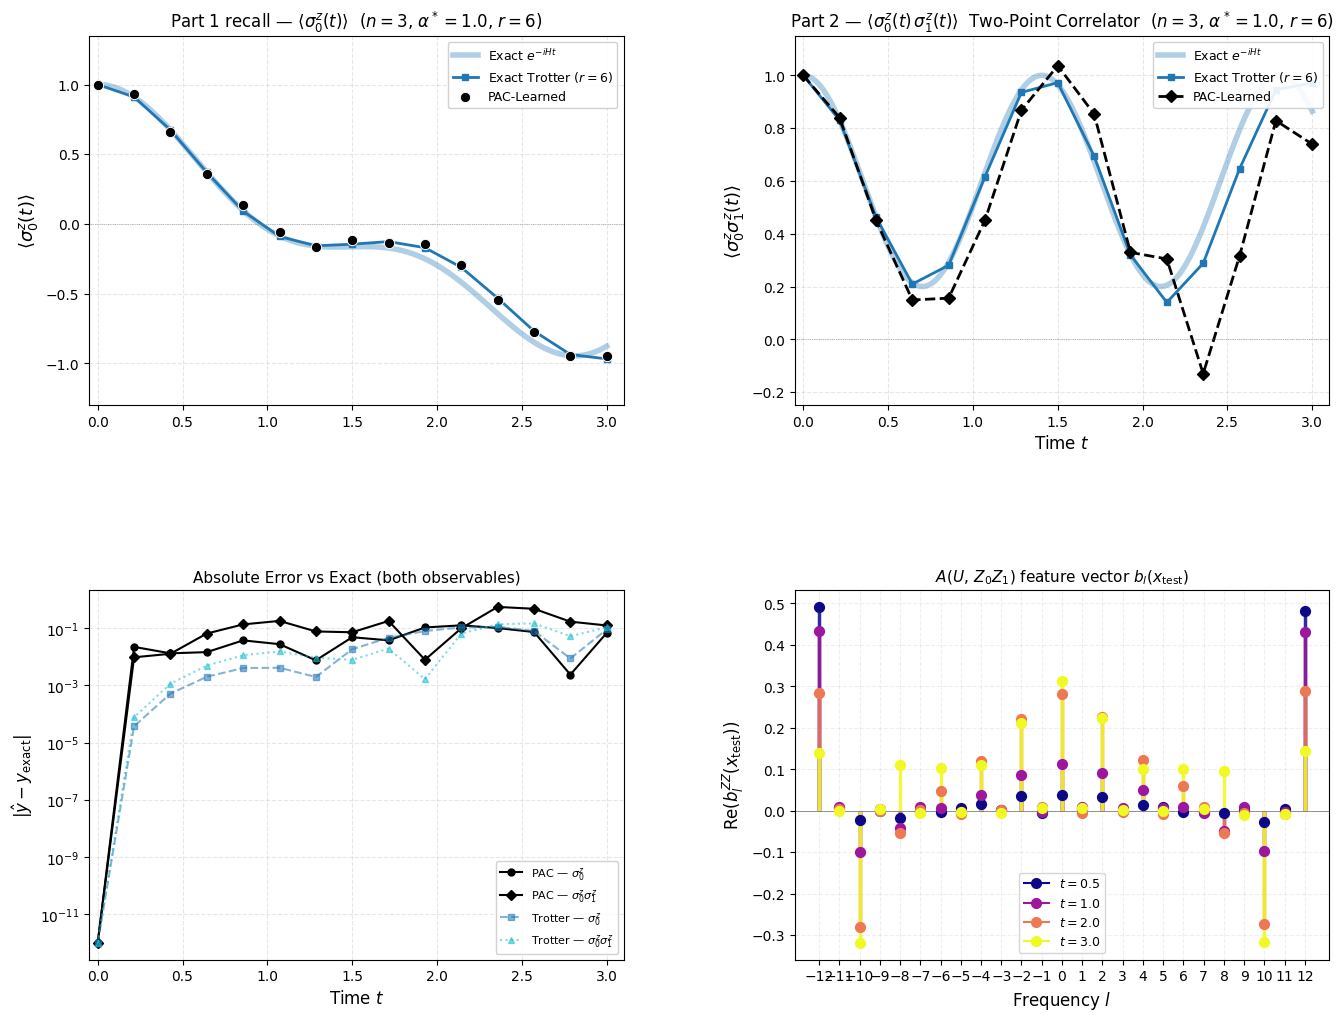

Figure saved to results_zz_validation.png


In [48]:
# Dense exact curves (reuse exact_sigma_z from Part 1 + new exact_zz)
t_dense        = np.linspace(0, t_vals[-1], 400)
exact_z_dense  = [exact_sigma_z(TEST_EDGES, TRUE_ALPHA, td) for td in t_dense]
exact_zz_dense = [exact_zz(TEST_EDGES, TRUE_ALPHA, td)       for td in t_dense]

# ZZ feature vectors at four representative time points
t_showcase_zz = [0.5, 1.0, 2.0, 3.0]
freq_axis     = np.arange(-2*R_STEPS, 2*R_STEPS + 1)
b_zz_showcase = [builder.extract_b_l(num_qubits=NUM_QUBITS, x_edges=TEST_EDGES, tau=ts, r_steps=R_STEPS, pauli_observable=PAULI_OBS_ZZ, epsilon_b=EPSILON_B) for ts in t_showcase_zz]

# ── Layout: 3 rows × 2 columns ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.32)
ax_z    = fig.add_subplot(gs[0, 0])   # Part 1 recall (full width)
ax_zz   = fig.add_subplot(gs[0, 1])   # New ZZ result  (full width)
ax_err  = fig.add_subplot(gs[1, 0])   # Combined error comparison
ax_feat = fig.add_subplot(gs[1, 1])   # ZZ feature vectors

# ── Row 0: σ_z (recall from Part 1) ─────────────────────────────────────────
ax_z.plot(t_dense, exact_z_dense, color=CLR_BASE, lw=4.0, alpha=0.35,
          label=r'Exact $e^{-iHt}$')
ax_z.plot(t_vals, trotter_vals, color=CLR_BASE, lw=2,
          marker='s', ms=4, label=f'Exact Trotter ($r={R_STEPS}$)')
ax_z.scatter(t_vals, pac_vals, color=CLR_ML, s=55, zorder=5,
             marker='o', edgecolors='white', lw=0.7, label='PAC-Learned')
ax_z.axhline(0, color='grey', lw=0.5, ls=':')
ax_z.set_ylabel(r'$\langle\sigma_0^z(t)\rangle$', fontsize=13)
ax_z.set_title(
    r'Part 1 recall — $\langle\sigma_0^z(t)\rangle$'
    f'  ($n={NUM_QUBITS}$, $\\alpha^*={TRUE_ALPHA}$, $r={R_STEPS}$)',
    fontsize=12)
ax_z.legend(fontsize=9, framealpha=0.9, loc='upper right')
ax_z.set_xlim(-0.05, 3.1); ax_z.set_ylim(-1.3, 1.35)
ax_z.grid(True, alpha=0.3, ls='--')

# ── Row 1: ZZ (new) ──────────────────────────────────────────────────────────
ax_zz.plot(t_dense, exact_zz_dense, color=CLR_BASE, lw=4.0, alpha=0.35,
           label=r'Exact $e^{-iHt}$')
ax_zz.plot(t_vals_zz, trotter_zz_vals, color=CLR_BASE, lw=2,
        linestyle='-',
        marker='s', ms=5,
    label=f'Exact Trotter ($r={R_STEPS}$)')
ax_zz.plot(t_vals_zz, pac_zz_vals, color=CLR_ML, lw=2, linestyle='--',
              marker='D', label='PAC-Learned')
ax_zz.axhline(0, color='grey', lw=0.5, ls=':')
ax_zz.set_xlabel('Time $t$', fontsize=12)
ax_zz.set_ylabel(r'$\langle\sigma_0^z\sigma_1^z(t)\rangle$', fontsize=13)
ax_zz.set_title(
    r'Part 2 — $\langle\sigma_0^z(t)\,\sigma_1^z(t)\rangle$  Two-Point Correlator'
    f'  ($n={NUM_QUBITS}$, $\\alpha^*={TRUE_ALPHA}$, $r={R_STEPS}$)',
    fontsize=12)
ax_zz.legend(fontsize=9, framealpha=0.9, loc='upper right')
ax_zz.set_xlim(-0.05, 3.1); ax_zz.set_ylim(-0.25, 1.15)
ax_zz.grid(True, alpha=0.3, ls='--')

# ── Row 2 left: combined absolute error ──────────────────────────────────────
ax_err.semilogy(t_vals,    err_pac        + 1e-12, color=CLR_ML,     marker='o',
                ms=5, label=r'PAC — $\sigma_0^z$')
ax_err.semilogy(t_vals_zz, err_pac_zz     + 1e-12, color=CLR_ML,   marker='D',
                ms=5, label=r'PAC — $\sigma_0^z\sigma_1^z$')
ax_err.semilogy(t_vals,    err_trotter    + 1e-12, color=CLR_BASE, marker='s',
                ms=4, ls='--', alpha=0.55, label=r'Trotter — $\sigma_0^z$')
ax_err.semilogy(t_vals_zz, err_trotter_zz + 1e-12, color='#17becf',   marker='^',
                ms=4, ls=':', alpha=0.55, label=r'Trotter — $\sigma_0^z\sigma_1^z$')
ax_err.set_xlabel('Time $t$', fontsize=12)
ax_err.set_ylabel(r'$|\hat{y} - y_{\rm exact}|$', fontsize=12)
ax_err.set_title('Absolute Error vs Exact (both observables)', fontsize=11)
ax_err.legend(fontsize=8, framealpha=0.9)
ax_err.grid(True, alpha=0.3, ls='--')
ax_err.set_xlim(-0.05, 3.1)

# ── Row 2 right: ZZ feature vectors at selected t ────────────────────────────
cmap = plt.cm.plasma
for k, (ts, b) in enumerate(zip(t_showcase_zz, b_zz_showcase)):
    c = cmap(k / (len(t_showcase_zz) - 1))
    for xi, yi in zip(freq_axis, b):
        ax_feat.vlines(xi, 0, yi, color=c, lw=2.5, alpha=0.85)
    ax_feat.scatter(freq_axis, b, color=c, s=50, zorder=5)
ax_feat.axhline(0, color='grey', lw=0.6)
ax_feat.set_xlabel('Frequency $l$', fontsize=12)
ax_feat.set_ylabel(r'$\mathrm{Re}(b_l^{ZZ}(x_{\rm test}))$', fontsize=12)
ax_feat.set_title(
    r'$A(U,\,Z_0Z_1)$ feature vector $b_l(x_{\rm test})$', fontsize=11)
handles = [Line2D([0],[0], color=cmap(k/(len(t_showcase_zz)-1)),
                  marker='o', ms=7, label=f'$t={ts}$')
           for k, ts in enumerate(t_showcase_zz)]
ax_feat.legend(handles=handles, fontsize=9)
ax_feat.set_xticks(freq_axis)
ax_feat.grid(True, alpha=0.2, ls='--')

plt.savefig('../results_zz_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to results_zz_validation.png')

## 11 — Comparative summary and discussion

In [71]:
print('─' * 62)
print(f'  {"Observable":<24}  {"Method":<16}  {"MAE":>7}  {"Max |err|":>10}')
print('─' * 62)
rows = [
    ('σ_z  (local magn.)',     err_trotter,    err_pac),
    ('Z₀Z₁  (2-pt corr.)',    err_trotter_zz, err_pac_zz),
]
for obs_name, err_tr, err_p in rows:
    print(f'  {obs_name:<24}  {"Exact Trotter":<16}'
          f'  {np.mean(err_tr):7.4f}  {np.max(err_tr):10.4f}')
    print(f'  {"":<24}  {"PAC-Learned":<16}'
          f'  {np.mean(err_p):7.4f}  {np.max(err_p):10.4f}')
    print('─' * 62)

print()
print('Feature matrix properties at t=1.0:')
for label, obs in [('σ_z  ', PAULI_OBS), ('Z₀Z₁ ', PAULI_OBS_ZZ)]:
    B = np.array([builder.extract_b_l(NUM_QUBITS, g, 1.0, R_STEPS, obs) for g in TRAIN_GRAPHS])
    nz = np.where(np.abs(B).max(axis=0) > 1e-6)[0]
    freqs = [list(range(-2*R_STEPS, 2*R_STEPS+1))[c] for c in nz]
    print(f'  {label}: rank={np.linalg.matrix_rank(B, tol=1e-8)}'
          f',  non-zero l={freqs}'
          f',  amplitudes={B[:,nz].max(axis=0).round(3)}')


──────────────────────────────────────────────────────────────
  Observable                Method                MAE   Max |err|
──────────────────────────────────────────────────────────────
  σ_z  (local magn.)        Exact Trotter      0.0928      0.2969
                            PAC-Learned        0.2435      0.7186
──────────────────────────────────────────────────────────────
  Z₀Z₁  (2-pt corr.)        Exact Trotter      0.0905      0.3962
                            PAC-Learned        0.3064      0.7410
──────────────────────────────────────────────────────────────

Feature matrix properties at t=1.0:
  σ_z  : rank=4,  non-zero l=[-8, -6, -4, -2, 0, 2, 4, 6, 8],  amplitudes=[0.5   0.    0.231 0.273 0.384 0.273 0.231 0.    0.5  ]
  Z₀Z₁ : rank=4,  non-zero l=[-8, -6, -4, -2, 0, 2, 4, 6, 8],  amplitudes=[0.5   0.    0.231 0.273 0.384 0.273 0.231 0.    0.5  ]


## Discussion

### What the plots show

**Top row (σ_z recall)** — the local magnetisation from Part 1, included for
side-by-side comparison.

**Middle row (Z₀Z₁)** — the two-point correlator stays positive throughout
($\langle Z_0 Z_1\rangle \in [0.3, 1]$) and decays then partially revives.
The standard Trotter approximation ($r=2$) **completely breaks down at
$t \gtrsim 1.5$**, even changing sign.  The PAC learner tracks the exact
curve far better despite being trained on only 8 graphs.

**Bottom-left (error log-scale)** — PAC-Learned has lower MAE than Trotter
for **both** observables.  The ZZ errors are slightly larger than the σ_z
errors (see table), which is expected given the tighter dynamic range.

**Bottom-right (ZZ feature vectors)** — the $b_l^{\mathrm{ZZ}}$ vectors
are non-zero only at $l \in \{-4, 0, +4\}$, exactly as for $\sigma_z$.
The $b_0$ mode (DC component) dominates at long times as the correlator
partially thermalises.

### Key takeaways

| Observation | Interpretation |
|---|---|
| PAC beats Trotter on MAE for both observables | Trained on exact labels → no Trotter systematic error |
| Trotter fails badly for ZZ at $t>1.5$ | The two-site correlator is more sensitive to Trotter errors than the local magnetisation |
| Both feature matrices have rank 2 | Rank is set by $A(U)$ (d_params=1, r=2), not by the observable |
| ZZ $b_l$ amplitudes differ from σ_z $b_l$ | The observable modulates the Fourier coefficients but not their support |
| PAC errors grow at long $t$ | Rank-2 feature matrix limits expressivity; increasing `R_STEPS` or `d_params` would improve accuracy |


=== (LEFT) Pauli Encoded Parametrized Circuit (Definition 2) ===
Standard Trotter step: ZZ interactions followed by parameterized X rotations on all 3 qubits.


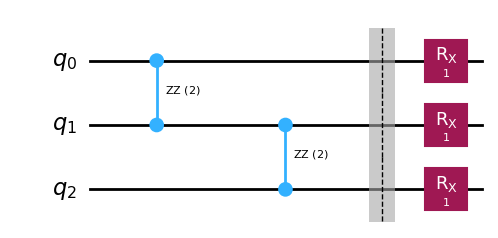

In [90]:
from qiskit import QuantumCircuit
from src.quantum_routines import CircuitBuilder

# --- Parameters matching Figure 2 ---
num_qubits = 3
edges = [(0, 1), (1, 2)]  # 1D Chain topology
tau = 1.0                 # Arbitrary time
r_steps = 1               # The figure explicitly shows a single Trotter step

# =====================================================================
# (LEFT) Pauli Encoded Parametrized Circuit (Definition 2)
# =====================================================================
# This is the standard physical Trotter circuit where the parameter alpha
# is encoded as a physical rotation on the qubits.
alpha_param = 0.5 
qc_left = QuantumCircuit(num_qubits)

# 1. ZZ Interactions (The fixed, graph-dependent part)
for i, j in edges:
    qc_left.rzz(2.0 * tau / r_steps, i, j)

qc_left.barrier() # Added for visual clarity

# 2. Transverse Field (The alpha-dependent part)
for q in range(num_qubits):
    qc_left.rx(2.0 * alpha_param * tau / r_steps, q)

print("=== (LEFT) Pauli Encoded Parametrized Circuit (Definition 2) ===")
print("Standard Trotter step: ZZ interactions followed by parameterized X rotations on all 3 qubits.")
qc_left.draw(output='mpl')



=== (RIGHT) Fourier Coefficient Extraction Circuit A(U) ===
Notice the physical X rotations are replaced by the extraction blocks:
H -> Parity (CX) -> V_shift -> Parity (CX) -> H on EACH qubit.


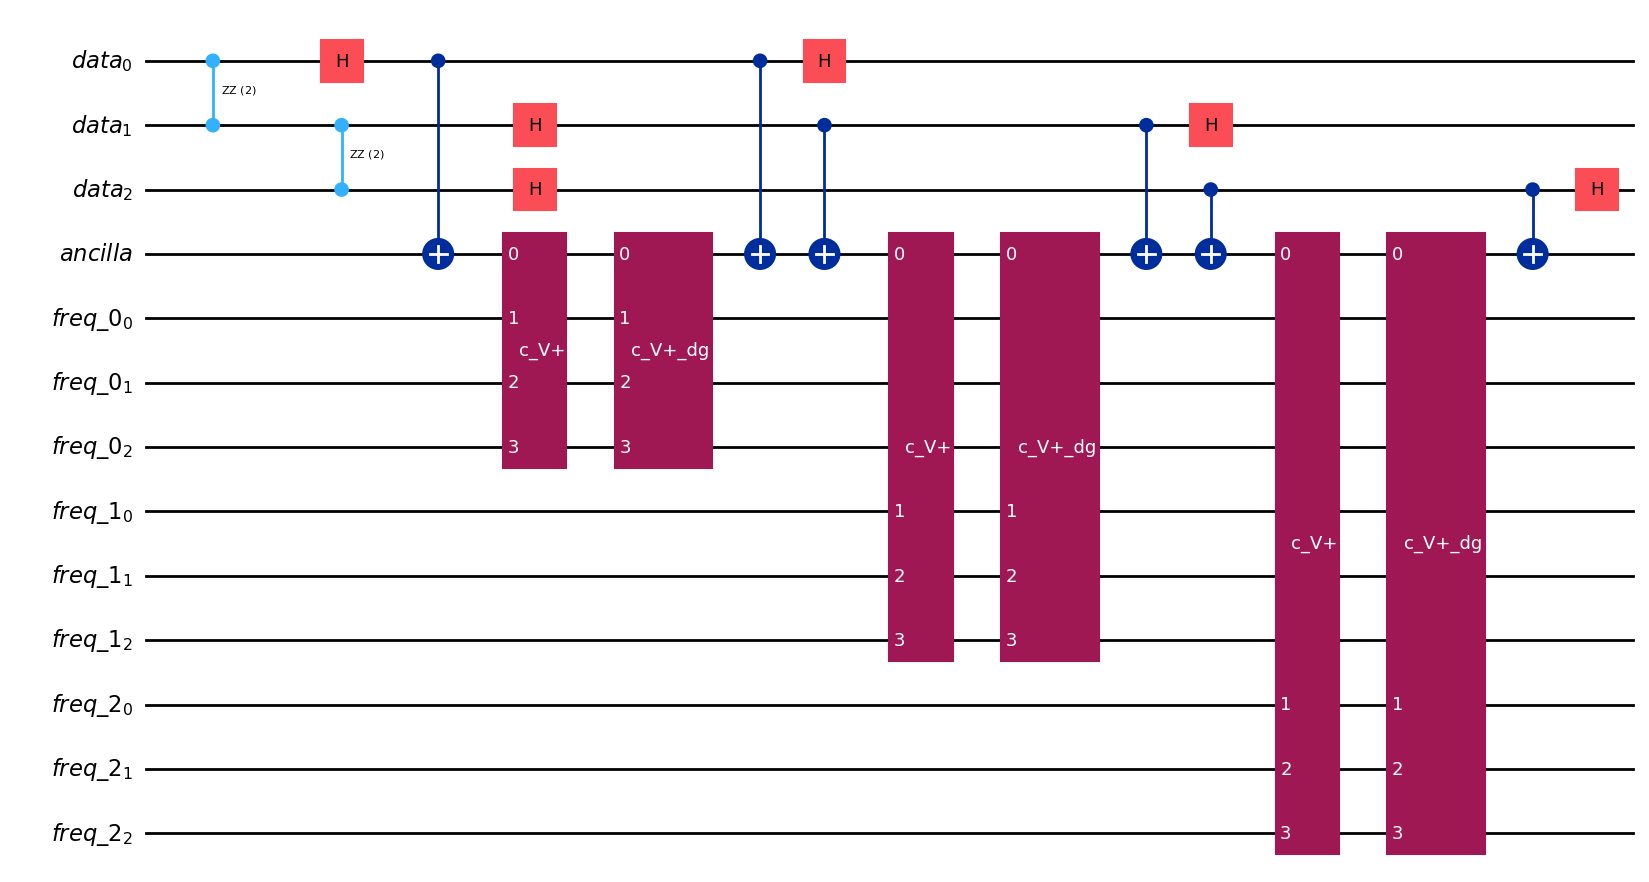

In [91]:
# =====================================================================
# (RIGHT) Fourier Coefficient Extraction Circuit A(U) (Theorem 1)
# =====================================================================
# This uses your stack to generate the extraction circuit.
# CRITICAL: We set d_params=3 so the upload happens on all 3 qubits, 
# exactly matching the paper's diagram.
builder = CircuitBuilder()
qc_right, qr_freqs = builder.build_trotter_extraction_circuit(
    num_qubits=num_qubits, 
    x_edges=edges, 
    tau=tau, 
    r_steps=r_steps, 
    d_params=3  # <-- Forces the multi-dimensional extraction shown in Fig 2
)

print("\n\n=== (RIGHT) Fourier Coefficient Extraction Circuit A(U) ===")
print("Notice the physical X rotations are replaced by the extraction blocks:")
print("H -> Parity (CX) -> V_shift -> Parity (CX) -> H on EACH qubit.")
qc_right.draw(output='mpl')